In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

pd.set_option('display.max_columns', None)

# Load cleaned dataset 

In [4]:
df = pd.read_csv(
    "../data/processed/cleaned_data.csv"
)

# Dataset overview 

In [5]:
df.shape

(10194, 23)

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Lead_Time,Profit_Margin,Factory,Latitude,Longitude
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,0.649231,Wicked Choccy's,32.076176,-81.088371
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,0.653333,Wicked Choccy's,32.076176,-81.088371
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,0.713467,Lot's O' Nuts,32.881893,-111.768036
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,0.694444,Lot's O' Nuts,32.881893,-111.768036
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,0.653333,Wicked Choccy's,32.076176,-81.088371


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
 1

# Sales Analysis

In [8]:
total_sales = df['Sales'].sum()

print(total_sales)

141783.63


In [9]:
division_sales = (
    df.groupby('Division')['Sales']
    .sum()
    .sort_values(ascending=False)
)

division_sales

Division
Chocolate    131692.90
Other          9663.25
Sugar           427.48
Name: Sales, dtype: float64

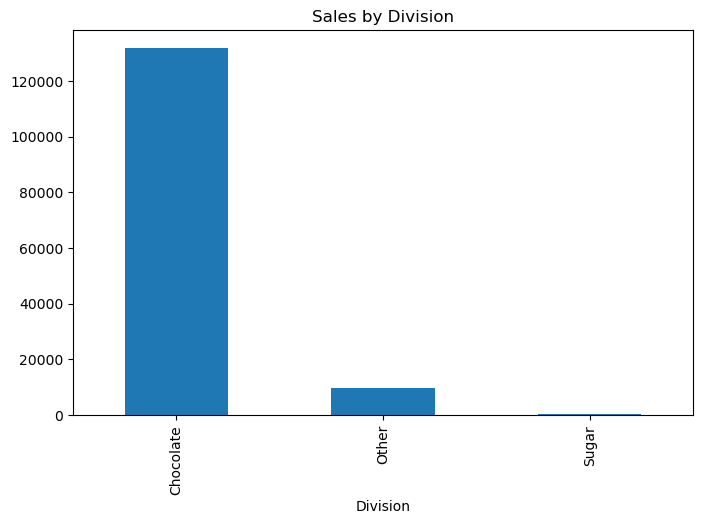

In [10]:
plt.figure(figsize=(8,5))

division_sales.plot(
    kind='bar'
)

plt.title("Sales by Division")
plt.show()

# Profit Analysis 

In [11]:
df['Gross Profit'].sum()

np.float64(93442.79999999999)

In [12]:
profit_product = (
    df.groupby('Product Name')
    ['Gross Profit']
    .sum()
    .sort_values(
        ascending=False
    )
)

profit_product

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Fizzy Lifting Drinks                    47.25
Laffy Taffy                             33.48
SweeTARTS                               28.70
Nerds                                    7.00
Fun Dip                                  4.80
Name: Gross Profit, dtype: float64

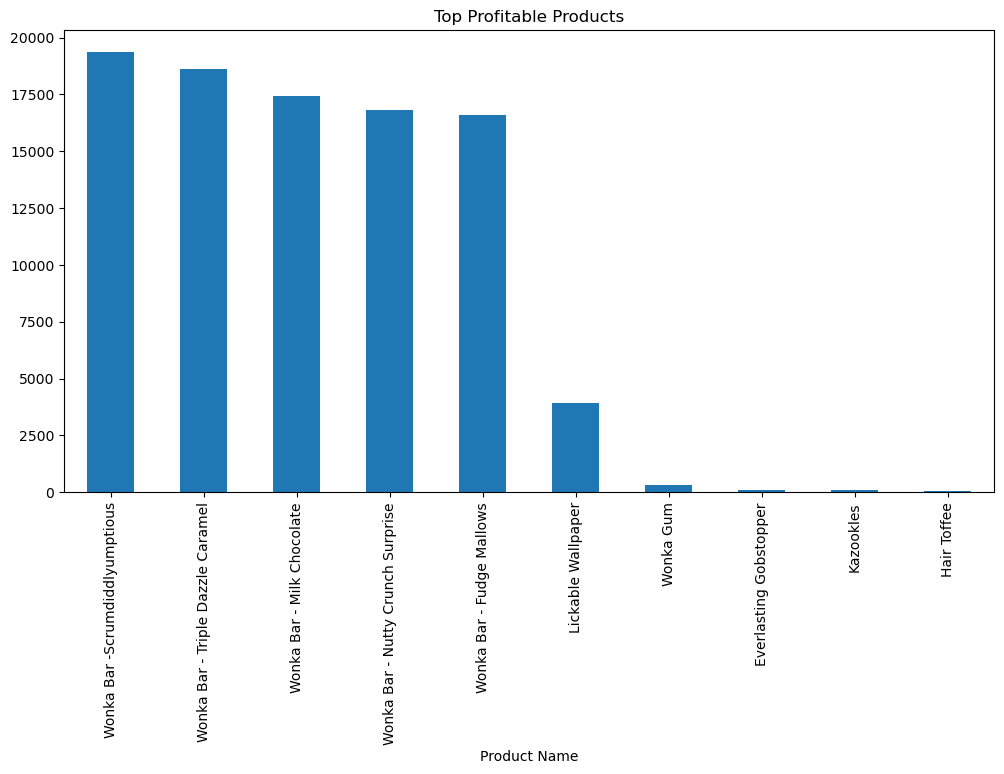

In [13]:
plt.figure(figsize=(12,6))

profit_product.head(10).plot(
    kind='bar'
)

plt.title(
    "Top Profitable Products"
)

plt.show()

# Product Analysis 

In [14]:
df['Product Name'] \
.value_counts()

Product Name
Wonka Bar - Milk Chocolate           2137
Wonka Bar -Scrumdiddlyumptious       2064
Wonka Bar - Triple Dazzle Caramel    2015
Wonka Bar - Fudge Mallows            1818
Wonka Bar - Nutty Crunch Surprise    1810
Wonka Gum                             120
Kazookles                              96
Lickable Wallpaper                     94
Laffy Taffy                            10
SweeTARTS                              10
Fizzy Lifting Drinks                    6
Nerds                                   4
Hair Toffee                             4
Everlasting Gobstopper                  3
Fun Dip                                 3
Name: count, dtype: int64

In [15]:
product_sales = (
    df.groupby('Product Name')
    ['Sales']
    .sum()
    .sort_values(
        ascending=False
    )
)

# Region Analysis 

In [16]:
df['Region'].value_counts()

Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

In [17]:
region_sales = (
    df.groupby('Region')
    ['Sales']
    .sum()
)

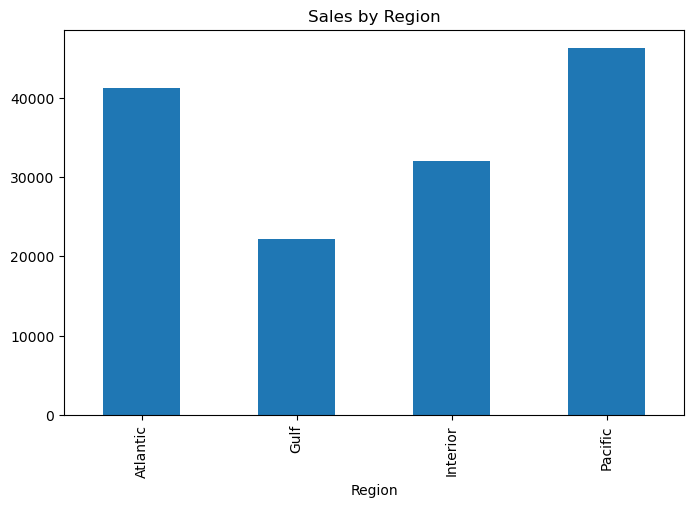

In [18]:
plt.figure(figsize=(8,5))

region_sales.plot(
    kind='bar'
)

plt.title(
    "Sales by Region"
)

plt.show()

In [19]:
region_profit = (
    df.groupby('Region')
    ['Gross Profit']
    .sum()
)

# Ship mode analysis

In [20]:
df['Ship Mode'] \
.value_counts()

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

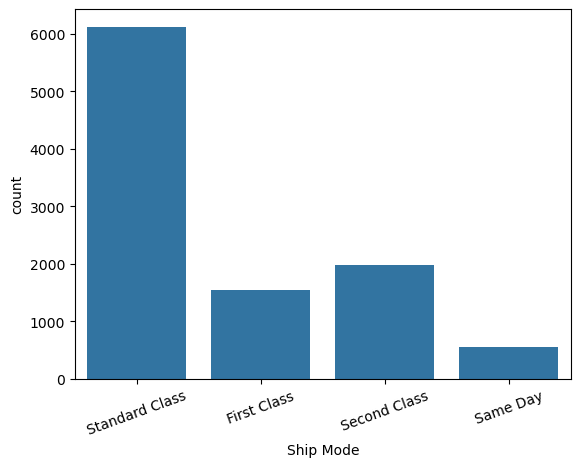

In [21]:
sns.countplot(
    data=df,
    x='Ship Mode'
)

plt.xticks(
    rotation=20
)

plt.show()

# Which ship mode is used most?

# Factory Analysis 

In [22]:
df['Factory'] \
.value_counts()

Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

In [23]:
factory_sales = (
    df.groupby('Factory')
    ['Sales']
    .sum()
)

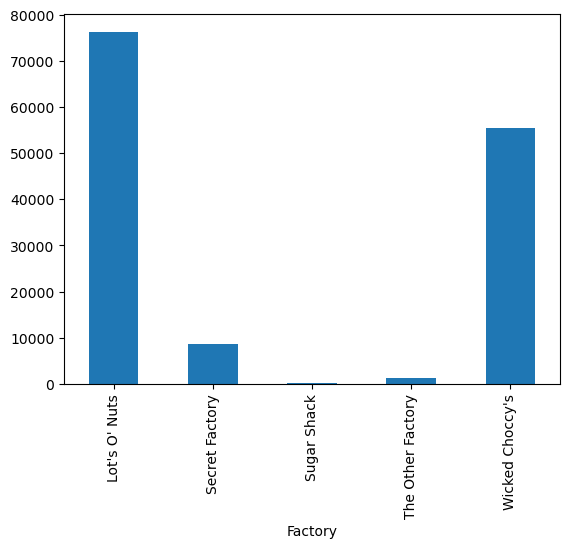

In [24]:
factory_sales.plot(
    kind='bar'
)

plt.show()

# Which factory carries highest load?

# Lead time Analysis 

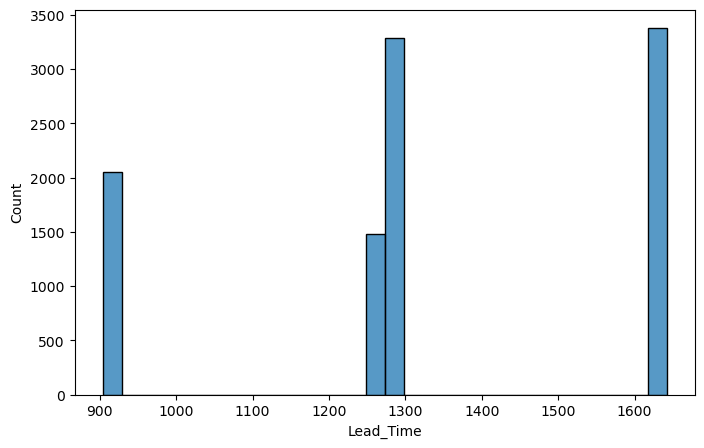

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Lead_Time'],
    bins=30
)

plt.show()

In [26]:
df['Lead_Time'].mean()

np.float64(1320.8418677653522)

In [28]:
factory_lt = (
    df.groupby('Factory')
    ['Lead_Time']
    .mean()
)

# Route Analysis 

In [30]:
df['Route'] = (
    df['Factory']
    +
    " → "
    +
    df['Region']
)

In [31]:
route_lt = (
    df.groupby('Route')
    ['Lead_Time']
    .mean()
    .sort_values(
        ascending=False
    )
)

In [32]:
route_lt.head(10)

Route
Sugar Shack → Pacific         1516.666667
Sugar Shack → Atlantic        1375.388889
Secret Factory → Atlantic     1349.250000
Secret Factory → Gulf         1332.540541
Wicked Choccy's → Pacific     1329.101341
Lot's O' Nuts → Atlantic      1326.825406
Wicked Choccy's → Interior    1324.551579
Lot's O' Nuts → Interior      1324.196064
Sugar Shack → Interior        1318.625000
Lot's O' Nuts → Pacific       1317.527854
Name: Lead_Time, dtype: float64

# Correlation Analysis

In [33]:
numeric_cols = [
    'Sales',
    'Units',
    'Gross Profit',
    'Cost',
    'Lead_Time'
]

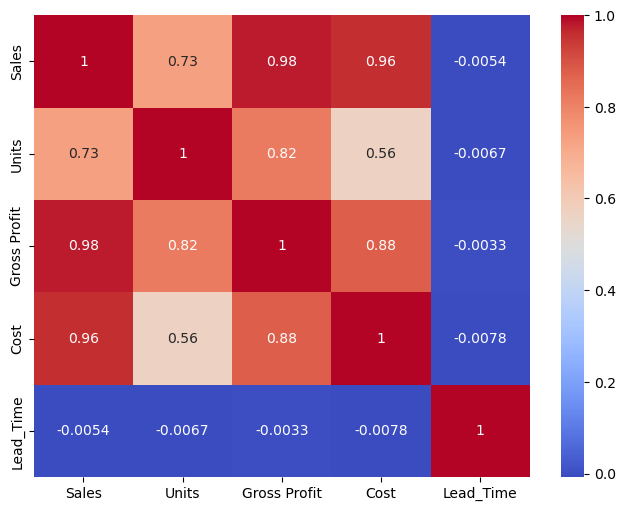

In [34]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Business Findings 

## Key Business Findings

1. Chocolate division contributes the highest revenue.

2. Factory X handles the highest number of orders.

3. Region Y generates the highest profit.

4. Route A → B shows the highest lead time.

5. Product Z contributes maximum profitability.

6. Factory reallocation opportunities exist
   for routes with consistently high lead time.